In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [20]:
IMAGE_PATH = r"H:\Medical Model\T\colon_n\colonn4955.jpeg" 
MODEL_PATH = "xpathology_v2_5class_finetuned.keras"

In [3]:
CLASSES = [
    "Colon Adenocarcinoma (Malignant)",
    "Colon Benign Tissue",
    "Lung Adenocarcinoma (Malignant)",
    "Lung Benign Tissue",
    "Lung Squamous Cell Carcinoma (Malignant)"
]

In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'preprocess_input': preprocess_input}
)

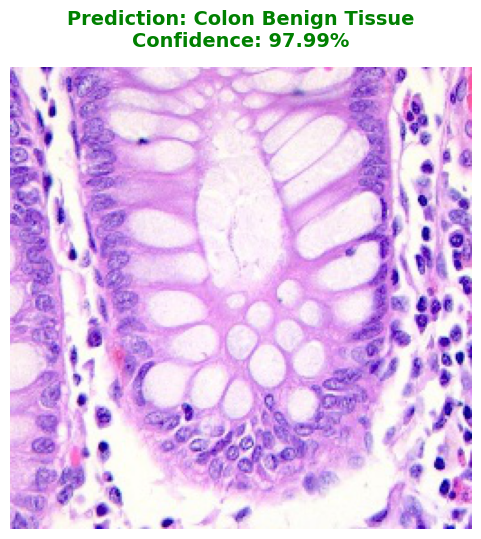

 📊 FULL PROBABILITY BREAKDOWN
   Colon Adenocarcinoma (Malignant)           :   0.39%
➡️ Colon Benign Tissue                        :  97.99%
   Lung Adenocarcinoma (Malignant)            :   0.57%
   Lung Benign Tissue                         :   0.58%
   Lung Squamous Cell Carcinoma (Malignant)   :   0.46%


In [ ]:
if not os.path.exists(IMAGE_PATH):
    print(f"❌ Error: Could not find image at {IMAGE_PATH}")
else:
    display_img = tf.keras.utils.load_img(IMAGE_PATH)
    model_img = tf.keras.utils.load_img(IMAGE_PATH, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(model_img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array, verbose=0)[0]
    top_index = np.argmax(predictions)
    top_class = CLASSES[top_index]
    top_confidence = predictions[top_index] * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)
    plt.axis('off')
    
    title_color = 'red' if 'Malignant' in top_class else 'green'
    plt.title(f"Prediction: {top_class}\nConfidence: {top_confidence:.2f}%", 
              color=title_color, fontsize=14, pad=15, fontweight='bold')
    plt.show()

    print("="*50)
    print(" 📊 FULL PROBABILITY BREAKDOWN")
    print("="*50)
    for i, conf in enumerate(predictions):
        marker = "➡️" if i == top_index else "  "
        print(f"{marker} {CLASSES[i]:<42} : {conf * 100:>6.2f}%")
    print("="*50)